# Importing necessary libraries

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.preprocessing import image
import tensorflow.keras.backend as K
from tensorflow.keras.utils import plot_model

 # Load and Preprocess the Dataset

In [2]:
data_dir = r"C:\Users\Frough\Desktop\internship\Animal Classification\dataset"  # change this!

In [3]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    zoom_range=0.25,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1
)

train_gen = datagen.flow_from_directory(
    data_dir, target_size=(224, 224), batch_size=32, class_mode='categorical', subset='training'
)

val_gen = datagen.flow_from_directory(
    data_dir, target_size=(224, 224), batch_size=32, class_mode='categorical', subset='validation', shuffle=False
)

class_names = list(val_gen.class_indices.keys())

Found 1561 images belonging to 15 classes.
Found 383 images belonging to 15 classes.


# MobileNetV2 + Training

In [4]:
base_mnet = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_mnet.trainable = False

x = GlobalAveragePooling2D()(base_mnet.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_gen.num_classes, activation='softmax')(x)

mobilenet_model = Model(inputs=base_mnet.input, outputs=output)
mobilenet_model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
mobilenet_model.fit(train_gen, validation_data=val_gen, epochs=20, callbacks=[early_stop])

C:\Users\Frough\AppData\Roaming\Python\Python310\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 41s 779ms/step - accuracy: 0.0910 - loss: 3.0282 - val_accuracy: 0.3185 - val_loss: 2.2908
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 37s 761ms/step - accuracy: 0.2451 - loss: 2.3907 - val_accuracy: 0.5483 - val_loss: 1.9372
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 37s 759ms/step - accuracy: 0.3540 - loss: 2.1007 - val_accuracy: 0.6475 - val_loss: 1.6480
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 37s 762ms/step - accuracy: 0.4716 - loss: 1.8342 - val_accuracy: 0.7023 - val_loss: 1.4036
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 37s 757ms/step - accuracy: 0.5841 - loss: 1.4704 - val_accuracy: 0.7728 - val_loss: 1.1672
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 37s 756ms/step - accuracy: 0.6277 - loss: 1.3843 - val_accuracy: 0.7781 - val_loss: 1.0394
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 37s 756ms/step - accuracy: 0.6589 - loss: 1.1683 - val_accuracy: 0.7546 - val_loss: 0.9485
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 37s 755ms/step - accuracy: 0.7060 - loss: 1.0796 - val_accu

# Fine-Tune MobileNetV2

In [5]:
base_mnet.trainable = True
for layer in base_mnet.layers[:-20]:
    layer.trainable = False

mobilenet_model.compile(optimizer=Adam(1e-6), loss='categorical_crossentropy', metrics=['accuracy'])
mobilenet_model.fit(train_gen, validation_data=val_gen, epochs=10, callbacks=[early_stop])

Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 45s 830ms/step - accuracy: 0.6802 - loss: 1.0203 - val_accuracy: 0.8172 - val_loss: 0.5959
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 39s 807ms/step - accuracy: 0.6972 - loss: 1.0085 - val_accuracy: 0.8329 - val_loss: 0.5973
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 39s 806ms/step - accuracy: 0.6906 - loss: 0.9908 - val_accuracy: 0.8120 - val_loss: 0.6055
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 39s 804ms/step - accuracy: 0.6998 - loss: 0.9784 - val_accuracy: 0.8486 - val_loss: 0.5611
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 39s 801ms/step - accuracy: 0.7060 - loss: 0.9778 - val_accuracy: 0.8094 - val_loss: 0.6104
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 39s 804ms/step - accuracy: 0.7110 - loss: 0.9424 - val_accuracy: 0.8538 - val_loss: 0.6012
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 39s 803ms/step - accuracy: 0.7228 - loss: 0.9489 - val_accuracy: 0.8251 - val_loss: 0.5839
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 39s 806ms/step - accuracy: 0.7357 - loss: 0.8645 - val_accu

# Grad-CAM Heatmap

In [6]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name='Conv_1', pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

In [7]:
# Display Heatmap Overlay
def save_and_display_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed = cv2.addWeighted(img, 1 - alpha, heatmap_color, alpha, 0)
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Grad-CAM")
    plt.show()

# Run Grad-CAM on a Validation Image

C:\Users\Frough\AppData\Roaming\Python\Python310\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


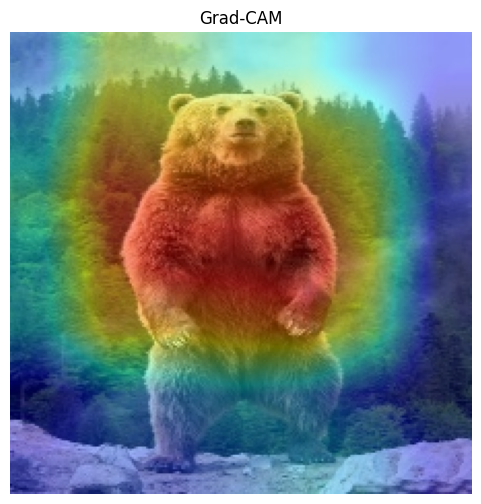

In [8]:
# Example: pick an image from validation set
idx = 0  # Change index to test other images
img_path = os.path.join(data_dir, val_gen.filenames[idx])
img_array = tf.keras.utils.img_to_array(image.load_img(img_path, target_size=(224, 224)))
img_array = np.expand_dims(img_array / 255.0, axis=0)

heatmap = make_gradcam_heatmap(img_array, mobilenet_model, last_conv_layer_name='Conv_1')
save_and_display_gradcam(img_path, heatmap)


# EfficientNetB0 + Training

In [9]:
base_eff = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_eff.trainable = False

x = GlobalAveragePooling2D()(base_eff.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_gen.num_classes, activation='softmax')(x)

efficientnet_model = Model(inputs=base_eff.input, outputs=output)
efficientnet_model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
efficientnet_model.fit(train_gen, validation_data=val_gen, epochs=20, callbacks=[early_stop])

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 52s 932ms/step - accuracy: 0.0661 - loss: 2.7352 - val_accuracy: 0.0914 - val_loss: 2.7083
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 43s 887ms/step - accuracy: 0.0555 - loss: 2.7216 - val_accuracy: 0.0679 - val_loss: 2.7090
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 43s 887ms/step - accuracy: 0.0643 - loss: 2.7233 - val_accuracy: 0.0653 - val_loss: 2.7089
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 43s 883ms/step - accuracy: 0.0720 - loss: 2.7099 - val_accuracy: 0.0705 - val_loss: 2.7090
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 43s 887ms/step - accuracy: 0.0598 - loss: 2.7147 - val_accuracy: 0.0705 - val_loss: 2.7080
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 43s 889ms/step - accuracy: 0.0789 - loss: 2.7093 - val_accuracy: 0.0705 - val_loss: 2.7078
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 43s 883ms/step - accuracy: 0.0737 - loss: 2.7088 - val_accuracy: 0.0679 - val_loss: 2.7077
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 43s 884ms/step - accuracy: 0.0662 - loss: 2.7085 - val_accu

# Fine-Tune EfficientNetB0

In [10]:
base_eff.trainable = True
for layer in base_eff.layers[:-30]:
    layer.trainable = False

efficientnet_model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
efficientnet_model.fit(train_gen, validation_data=val_gen, epochs=10, callbacks=[early_stop])

Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.0620 - loss: 2.7998 - val_accuracy: 0.0705 - val_loss: 2.7078
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 48s 980ms/step - accuracy: 0.0649 - loss: 2.7790 - val_accuracy: 0.0731 - val_loss: 2.7082
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.0574 - loss: 2.7454 - val_accuracy: 0.0679 - val_loss: 2.7085
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.0648 - loss: 2.7539 - val_accuracy: 0.0731 - val_loss: 2.7111
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.0634 - loss: 2.7332 - val_accuracy: 0.0653 - val_loss: 2.7144
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 49s 992ms/step - accuracy: 0.0618 - loss: 2.7481 - val_accuracy: 0.0653 - val_loss: 2.7168


# TTA Function

In [11]:
def predict_with_tta(model, generator, tta_steps=5):
    predictions = []
    for _ in range(tta_steps):
        generator.reset()
        preds = model.predict(generator, verbose=0)
        predictions.append(preds)
    return np.mean(predictions, axis=0)

# Ensemble with Weights

In [12]:
val_gen.reset()
tta_preds_mnet = predict_with_tta(mobilenet_model, val_gen, tta_steps=5)
tta_preds_eff = predict_with_tta(efficientnet_model, val_gen, tta_steps=5)

ensemble_preds = (0.6 * tta_preds_mnet + 0.4 * tta_preds_eff)
y_pred = np.argmax(ensemble_preds, axis=1)
y_true = val_gen.classes

print("🔮 Weighted TTA Ensemble Performance:")
print(classification_report(y_true, y_pred, target_names=class_names))

🔮 Weighted TTA Ensemble Performance:
              precision    recall  f1-score   support

        Bear       0.85      0.88      0.86        25
        Bird       0.81      0.93      0.86        27
         Cat       0.92      0.96      0.94        24
         Cow       0.72      0.81      0.76        26
        Deer       0.77      0.80      0.78        25
         Dog       0.82      0.58      0.68        24
     Dolphin       0.88      0.92      0.90        25
    Elephant       0.96      0.85      0.90        26
     Giraffe       1.00      1.00      1.00        25
       Horse       0.87      0.77      0.82        26
    Kangaroo       0.78      0.84      0.81        25
        Lion       0.82      0.88      0.85        26
       Panda       0.96      0.93      0.94        27
       Tiger       0.96      0.92      0.94        25
       Zebra       1.00      1.00      1.00        27

    accuracy                           0.87       383
   macro avg       0.87      0.87      0.87

# Wrap Ensemble in a Custom Python Function

In [13]:
def ensemble_predict(image_batch, mnet_model, eff_model, tta_steps=5):
    preds1 = np.mean([mnet_model.predict(image_batch) for _ in range(tta_steps)], axis=0)
    preds2 = np.mean([eff_model.predict(image_batch) for _ in range(tta_steps)], axis=0)
    return (0.6 * preds1 + 0.4 * preds2)


# Confusion Matrix (for Ensemble)

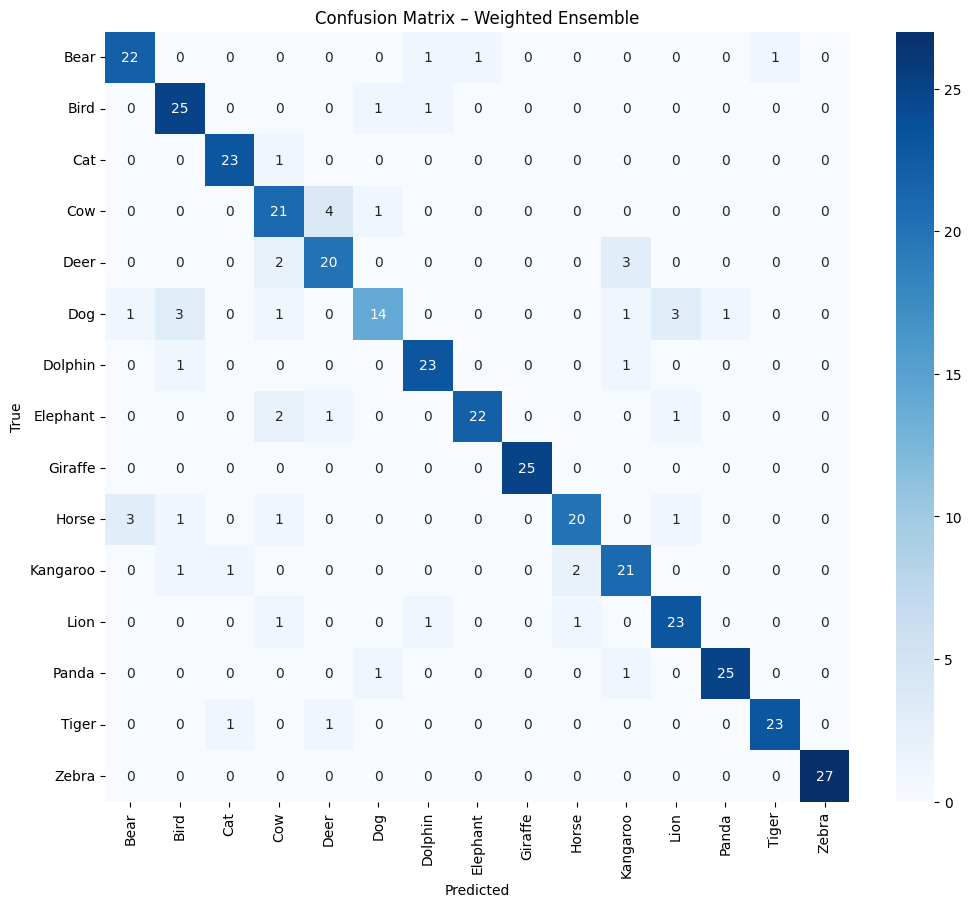

In [14]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix – Weighted Ensemble')
plt.show()


Model Architecture Understanding

In [15]:
mobilenet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 5,167,855 (19.71 MB)

 Trainable params: 1,371,983 (5.23 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

 Optimizer params: 2,743,968 (10.47 MB)

In [16]:
efficientnet_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 7,539,602 (28.76 MB)

 Trainable params: 1,662,063 (6.34 MB)

 Non-trainable params: 2,553,411 (9.74 MB)

 Optimizer params: 3,324,128 (12.68 MB)

# Save Both Models

In [17]:
mobilenet_model.save("mobilenetv2_best.h5")
efficientnet_model.save("efficientnetb0_best.h5")